In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Housing.csv')

In [3]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 545
Columns: 13


In [5]:
target = "price"
features = [col for col in df.columns if col != target]

print("Target Column:", target)
print("Feature Columns:")
print(features)

Target Column: price
Feature Columns:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
df = df.dropna() #null value
    

In [8]:
df = df.drop_duplicates() #duplicates

In [9]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns
print(categorical_cols)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')


In [10]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head() #encoding

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [11]:
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (545, 13)
Target Shape: (545,)


In [12]:
df_clean = pd.get_dummies(df, drop_first=True)

bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

df_clean.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [13]:
X = df_clean.drop("price", axis=1)
y = df_clean["price"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [15]:
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (436, 13)
Testing Features Shape: (109, 13)
Training Target Shape: (436,)
Testing Target Shape: (109,)


In [16]:
lr_model = LinearRegression()

In [17]:
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [18]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr) #linear regression

In [19]:
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)

MAE : 970043.403920164
RMSE: 1324506.9600914388
R² Score: 0.6529242642153184


In [20]:
rf_model = RandomForestRegressor(n_estimators=100,random_state=42)

In [21]:
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [22]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

In [23]:
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf) #random forest

MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699


In [24]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2 Score": [r2_lr, r2_rf]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


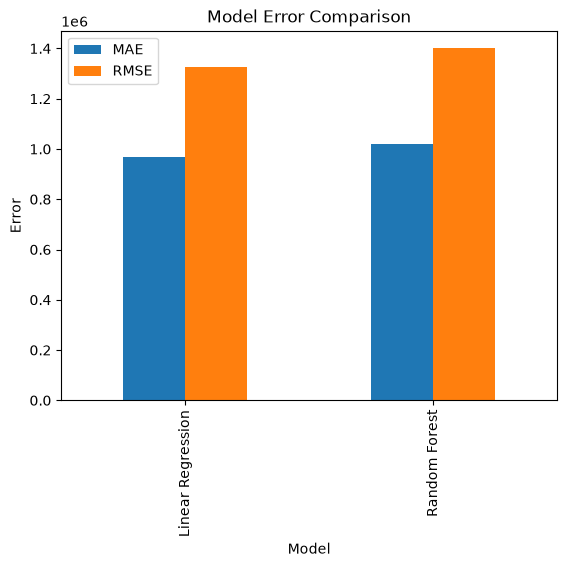

In [25]:
comparison.set_index("Model")[["MAE", "RMSE"]].plot(kind="bar")
plt.title("Model Error Comparison")
plt.ylabel("Error")
plt.show()

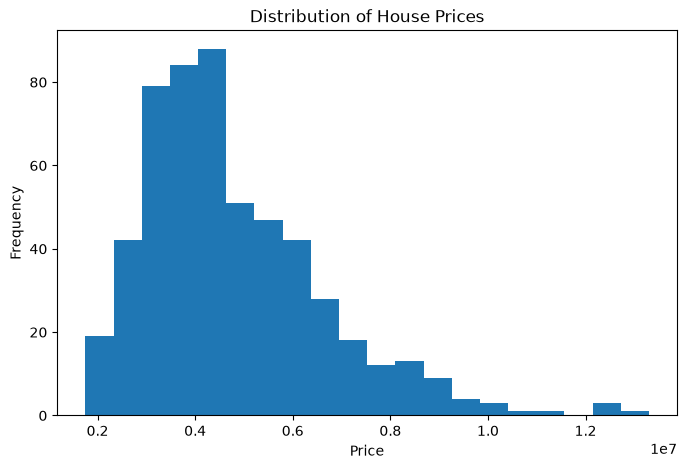

In [28]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=20)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show() #graph 1: histogram

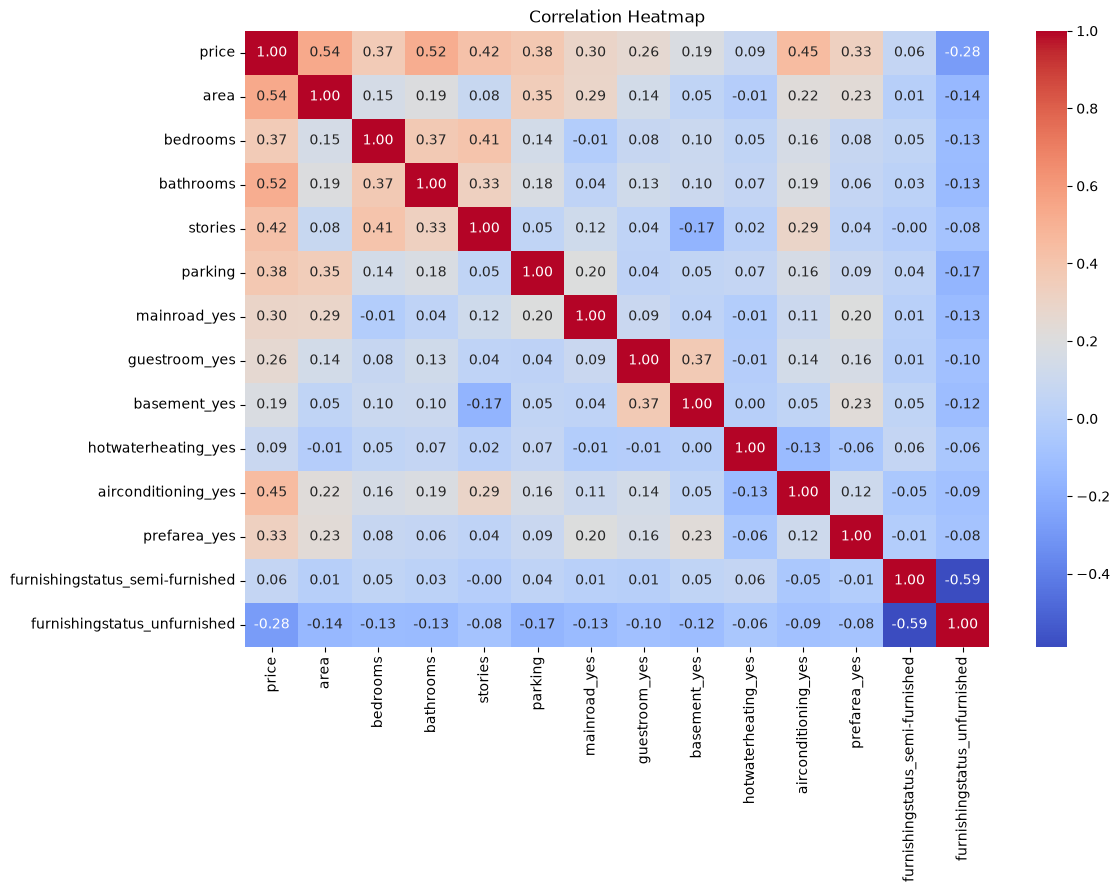

In [30]:
plt.figure(figsize=(12,8))
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show() #graph 2: correlation heatmap

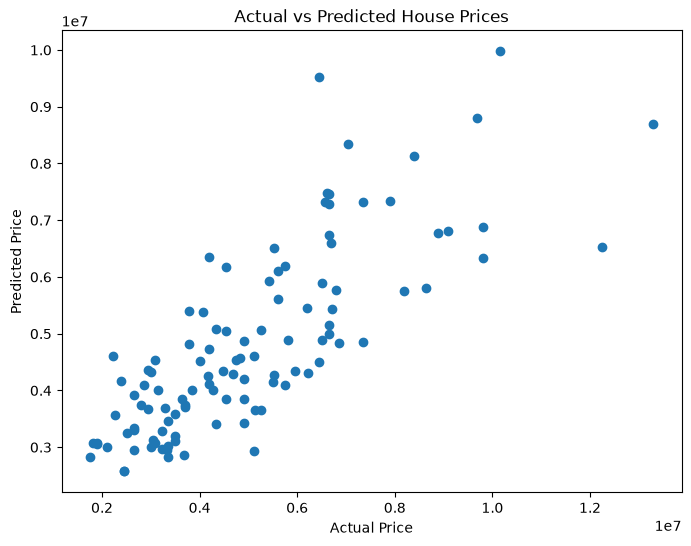

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

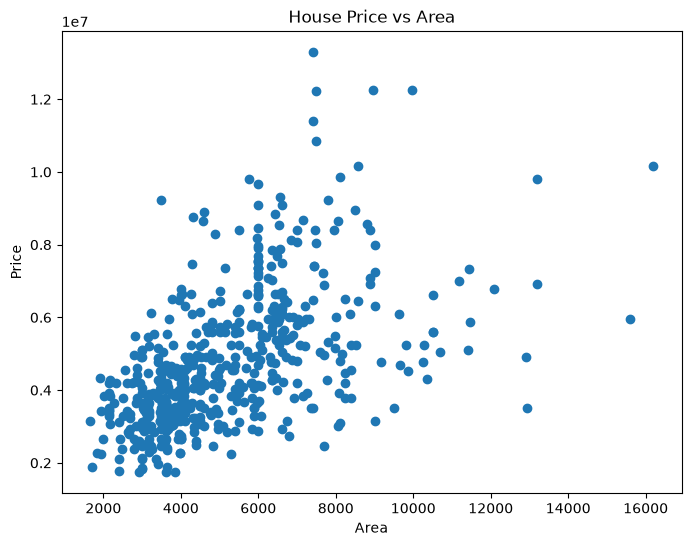

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(df["area"], df["price"])

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("House Price vs Area")

plt.show() #scatter plot
#positive relation - larger area costs more 

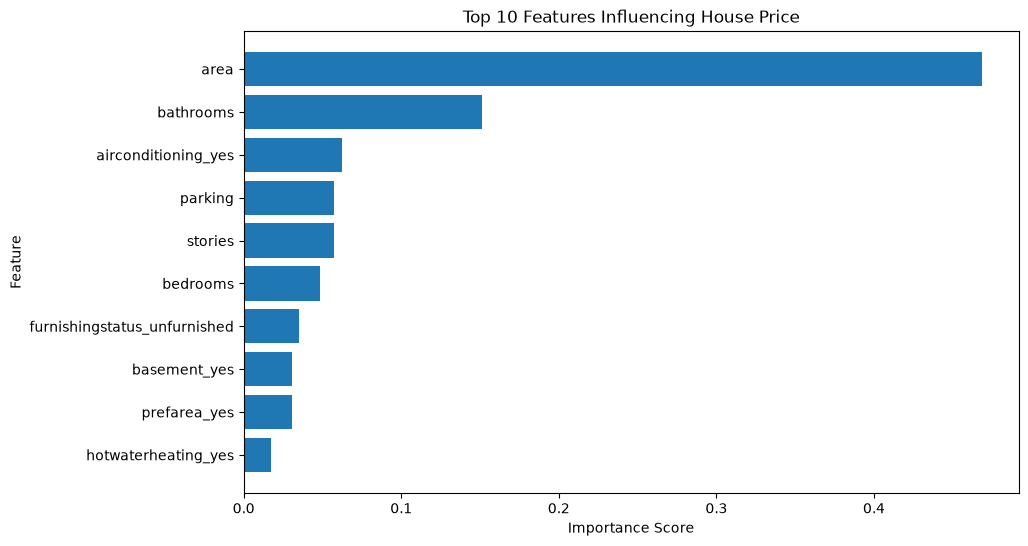

In [35]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)

plt.title('Top 10 Features Influencing House Price')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.gca().invert_yaxis()
plt.show()